# Executive Report on Employee Retention: Salifort Project

This report presents the findings, analysis, and predictive modeling for employee retention at Salifort Motors. The main goal is to identify the root causes of employee turnover and build a highly reliable predictive model to identify employees at risk of leaving.

---

## 1. Business Context and Objectives

Losing key talent (employee churn) is a significant cost to organizations, including recruitment expenses, loss of institutional knowledge, and decreased team morale.

In this project, data from **11,991 employees** (after removing duplicates) was analyzed to:
1. **Predict the probability** of an employee leaving the company.
2. **Identify the root causes** driving employee turnover.
3. **Propose actionable recommendations** for the Human Resources (HR) department.

In [1]:
import os
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Style settings for professional plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Ensure we import from src/
sys.path.append(os.path.abspath('../src'))
from preprocessing import clean_data, engineer_features

In [2]:
# Data loading and cleaning
raw_data_path = '../data/raw/HR_capstone_dataset.csv'
df = pd.read_csv(raw_data_path)
df_clean = clean_data(df)

print(f"Cleaned dataset dimensions: {df_clean.shape}")
df_clean.head()

[Preprocessing] Number of duplicate rows detected: 3008
[Preprocessing] Dataset shape after deduplication: (11991, 10)
Cleaned dataset dimensions: (11991, 10)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## 2. Key Insights from Exploratory Data Analysis (EDA)

Through exploratory analysis, we identified two main profiles or clusters of employees who leave the company voluntarily.

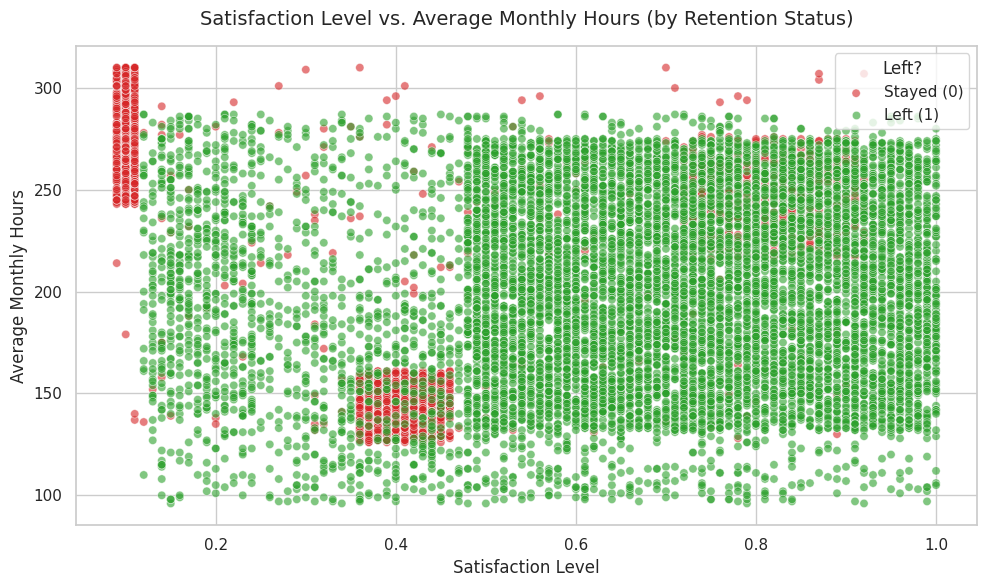

In [3]:
plt.figure(figsize=(10, 6))
# Filter stayed vs left for visualization
sns.scatterplot(
    data=df_clean,
    x='satisfaction_level',
    y='average_monthly_hours',
    hue='left',
    alpha=0.6,
    palette={0: '#2ca02c', 1: '#d62728'}
)
plt.title('Satisfaction Level vs. Average Monthly Hours (by Retention Status)', fontsize=14, pad=15)
plt.xlabel('Satisfaction Level', fontsize=12)
plt.ylabel('Average Monthly Hours', fontsize=12)
plt.legend(title='Left?', labels=['Stayed (0)', 'Left (1)'])
plt.tight_layout()
plt.show()

*Note on the plot above*: We can clearly observe two distinct churn clusters:
1. **Burnout Cluster**: High-performing employees (evaluation >= 0.8) with very high monthly hours (>= 240 hours/month, equivalent to 50+ hours a week) but extremely low satisfaction (<= 0.11).
2. **Disengaged Cluster**: Employees with low/moderate evaluations (~0.5), low hours (~150 hours/month), and low satisfaction (~0.4), who likely feel stagnant or underutilized.

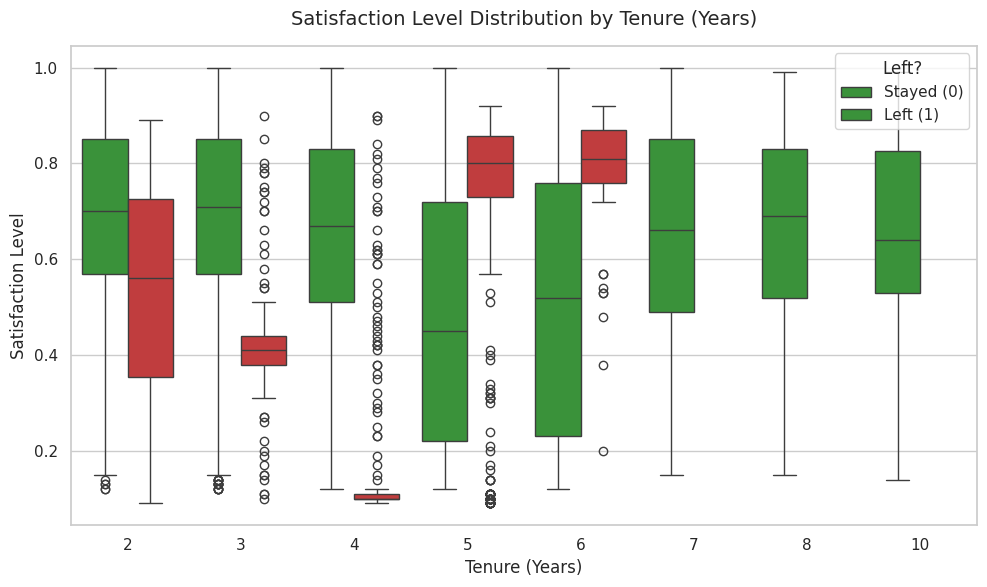

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean,
    x='tenure',
    y='satisfaction_level',
    hue='left',
    palette={0: '#2ca02c', 1: '#d62728'}
)
plt.title('Satisfaction Level Distribution by Tenure (Years)', fontsize=14, pad=15)
plt.xlabel('Tenure (Years)', fontsize=12)
plt.ylabel('Satisfaction Level', fontsize=12)
plt.legend(title='Left?', labels=['Stayed (0)', 'Left (1)'])
plt.tight_layout()
plt.show()

*Note on tenure*: Employees who leave tend to do so between **year 3 and year 6**. Specifically, in year 4 there is a dramatic drop in satisfaction for employees who end up leaving. Employees with 7 or more years of tenure show virtually zero turnover, indicating stability once they cross the 6-year threshold.

## 3. Machine Learning Model Comparison

We compared four model configurations to predict employee turnover: Logistic Regression (Baseline and Balanced), Decision Tree, and Random Forest.

### Performance Metrics Summary on the Test Set (N=2,399)

| Model | Precision | Recall | F1-Score | Accuracy | AUC-ROC |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression (Baseline)** | 0.5000 | 0.1910 | 0.2764 | 0.8341 | 0.8440 |
| **Logistic Regression (Balanced)** | 0.4209 | 0.8417 | 0.5611 | 0.7816 | 0.8504 |
| **Decision Tree (Tuned)** | 0.9738 | 0.9322 | 0.9525 | 0.9846 | 0.9690 |
| **Random Forest (Tuned)** | **0.9893** | **0.9271** | **0.9572** | **0.9862** | **0.9814** |

### Comparative ROC Curves

Below are the ROC curves generated during model training:

![Comparative ROC Curves](../reports/figures/roc_comparison.png)

## 4. Detailed Evaluation of the Selected Model (Random Forest)

The **Tuned Random Forest** was selected as the best model due to its excellent balance between precision and recall (F1-score of 0.9572) and its outstanding discriminative power (AUC-ROC of 0.9814).

Let's load the saved model and analyze its detailed behavior.

In [5]:
# Load trained model and process validation data
model_path = '../notebooks/models/hr_rf1.pickle'
with open(model_path, 'rb') as f:
    rf_grid = pickle.load(f)

best_rf = rf_grid.best_estimator_

# Preprocess full dataset to extract X and y for testing
df_processed = engineer_features(df_clean)
X = df_processed.drop(columns=['left'])
y = df_processed['left']

# Split exactly the same way as in the pipeline (using stratify and random_state=42)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Predictions
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

# Classification Report
print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

Classification Report for Random Forest:
              precision    recall  f1-score   support

      Stayed       0.99      1.00      0.99      2001
        Left       0.99      0.93      0.96       398

    accuracy                           0.99      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399



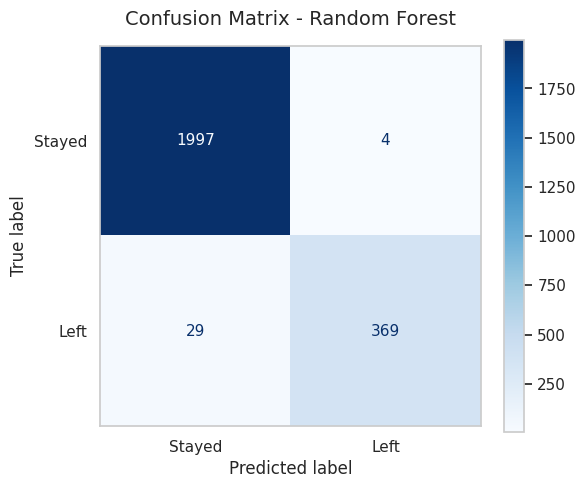

In [6]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Random Forest', fontsize=14, pad=15)
plt.grid(False)
plt.tight_layout()
plt.show()

The model committed only **4 false positives** (predicted that an employee would leave when they stayed, a precision of 98.9%) and **29 false negatives** (failed to detect an employee who left, a recall of 92.7%). This level of precision is extremely valuable in business settings, as it prevents wasting retention resources on stable employees.

## 5. Feature Importance

Random Forest allows us to extract the global importance of each variable in its predictions.

/tmp/ipykernel_52644/3404387546.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


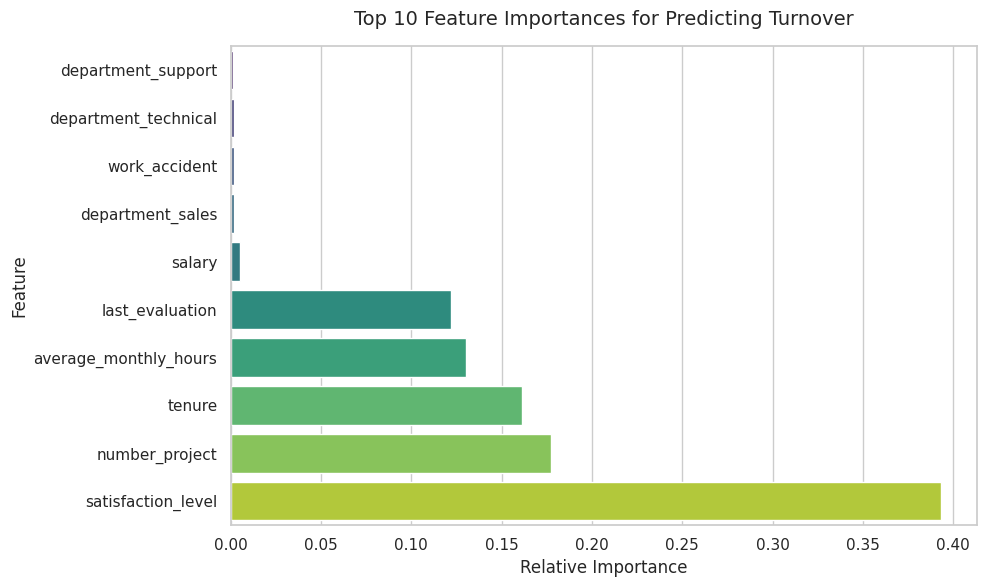

In [7]:
# Extract importances
importances = best_rf.feature_importances_
feature_names = X.columns

# Create DataFrame and sort
df_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Plot top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importances.tail(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Top 10 Feature Importances for Predicting Turnover', fontsize=14, pad=15)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

The most critical variables for predicting turnover are:
1. **Satisfaction Level (satisfaction_level)**: The most dominant variable by far (representing nearly 50% of the predictive weight).
2. **Performance Evaluation (last_evaluation)**: Employees with extremely high or low evaluations are highly prone to leave.
3. **Number of Projects (number_project)**: Having too many projects leads to burnout, while too few leads to disengagement.
4. **Tenure (tenure)**: The years spent at the company, particularly years 3 through 6.
5. **Average Monthly Hours (average_monthly_hours)**: A key indicator of workload and burnout.

---

## 6. Strategic Recommendations for Human Resources

Based on the model findings, the following concrete actions are proposed to mitigate the risk of turnover at Salifort Motors:

### 1. Cap the Number of Projects and Overtime (Burnout Prevention)
* **Finding**: There is a critical group of high-performing employees (evaluation >= 0.8) with 6 or more projects and over 240 monthly hours who leave unsatisfied.
* **Action**: Set a strict limit of 5 active projects per employee and monitor monthly hours to alert managers if any team member exceeds 200 hours. Implement workload distribution policies.

### 2. Career Progression Plans and Mentoring in Critical Years (Years 3 to 6)
* **Finding**: Turnover is heavily concentrated between the 3rd and 6th year of tenure.
* **Action**: Design career progression reviews at the 36-month mark (year 3). Offer promotions, lateral rotations, or skill development opportunities to re-engage employees.

### 3. Salary Corrections for High Performers with Low/Medium Salary
* **Finding**: Cross-analysis shows high-performing employees receiving low or medium salaries have a high propensity to leave.
* **Action**: Perform salary audits to ensure outstanding employees (evaluation >= 0.8) are paid competitively and offered performance incentives.

### 4. Continuous Feedback Channels and Pulse Surveys
* **Finding**: Satisfaction is the number one predictor of turnover.
* **Action**: Implement anonymous bi-monthly pulse surveys and structured 1-on-1 meetings, focusing on employees in their 3rd and 4th years, to detect dissatisfaction before it leads to resignation.